# Predicting Taxi Tips & Optimizing Fleet Revenue
**Objective:** 
- Predicting the expected tip amount for a passenger based on time of day, geography, and distance, to improve driver dispatching, shift profitability, and fleet deployment strategies.

- Tips are a non-trivial component of a driver's take-home pay, often determining whether a specific route is financially viable.

- Poor route selection and blind dispatching force drivers into high-traffic, low-yield "dead zones," distorting their hourly margins and wasting fuel.

- Automating tip estimation helps fleet managers forecast the true financial yield of a neighborhood before dispatching a driver to that zone.

## Hypotheses
1. The Spatial-Temporal Effect: Tip amounts are not strictly bound to distance; they are heavily influenced by the specific pickup borough and the time of day (e.g., Evening Rush vs. Midday).

2. The Non-Linearity of Human Behavior: While longer trips generally yield higher tips, human tipping behavior becomes highly erratic at longer distances (heteroskedasticity), meaning traditional linear models will fail, and advanced tree-based models (like Random Forest) will be required to accurately map the variance.

3. The Data Leakage Trap: A robust predictive model must accurately forecast tips using only pre-trip logistical data (Time, Distance, Location), actively excluding post-trip financial metrics (Total Fare) to ensure the model is viable for real-world dispatching.

In [28]:
import pandas as pd
import duckdb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [3]:
# 1. Load the pristine data!
con = duckdb.connect()
clean_data_path = 'data/cleaned_taxi_data_for_ml.parquet'
print("⏳ Loading data...")
df = con.execute(f"SELECT * FROM '{clean_data_path}'").df()

⏳ Loading data...


In [5]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,day_of_week,PULocationID,pickup_zone,pickup_borough,DOLocationID,dropoff_zone,dropoff_borough,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2026-03-22 06:46:03,2026-03-22 06:54:49,6,7,137,Kips Bay,Manhattan,100,Garment District,Manhattan,1,1.29,1,10.0,2.21,16.96
1,2026-03-22 06:57:58,2026-03-22 07:00:56,6,7,100,Garment District,Manhattan,43,Central Park,Manhattan,1,1.14,1,6.5,3.00,14.25
2,2026-03-22 06:12:29,2026-03-22 06:17:30,6,7,43,Central Park,Manhattan,100,Garment District,Manhattan,1,1.30,2,7.9,0.00,12.65
3,2026-03-22 06:42:19,2026-03-22 07:06:35,6,7,237,Upper East Side South,Manhattan,138,LaGuardia Airport,Queens,2,9.19,1,38.0,7.16,54.91
4,2026-03-22 06:42:56,2026-03-22 06:54:28,6,7,230,Times Sq/Theatre District,Manhattan,144,Little Italy/NoLiTa,Manhattan,1,3.10,1,14.9,2.00,21.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2884455,2026-03-22 06:21:57,2026-03-22 06:32:25,6,7,238,Upper West Side North,Manhattan,237,Upper East Side South,Manhattan,1,2.22,1,13.5,3.70,22.20
2884456,2026-03-22 06:56:48,2026-03-22 07:02:21,6,7,238,Upper West Side North,Manhattan,263,Yorkville West,Manhattan,1,1.54,1,9.3,3.33,16.63
2884457,2026-03-22 06:38:11,2026-03-22 06:40:36,6,7,90,Flatiron,Manhattan,186,Penn Station/Madison Sq West,Manhattan,1,0.80,1,5.8,2.11,12.66
2884458,2026-03-22 06:37:08,2026-03-22 07:02:42,6,7,90,Flatiron,Manhattan,129,Jackson Heights,Queens,1,7.55,1,34.5,7.85,47.10


In [7]:
# 2. The Business Filter: Keep ONLY Credit Card trips
df_filtered = df[df['payment_type'] == 1].copy()
print(f"💳 Credit Card trips available: {len(df_filtered):,}")

💳 Credit Card trips available: 2,534,709


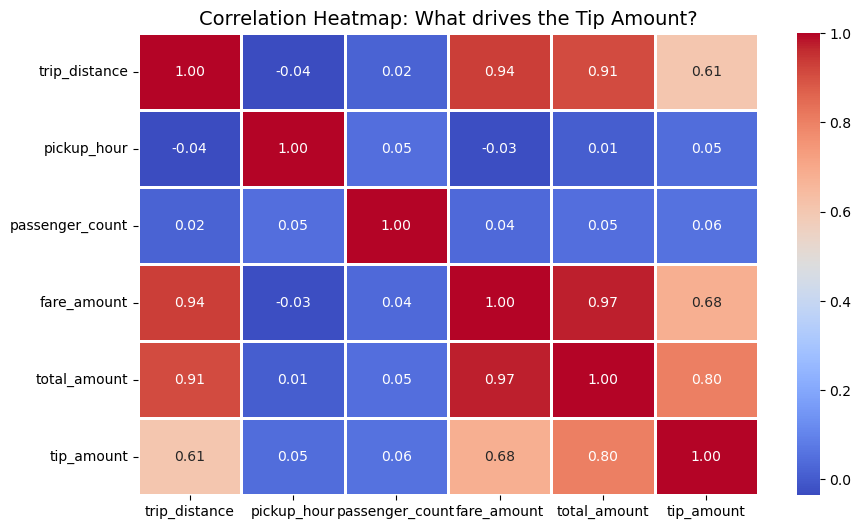

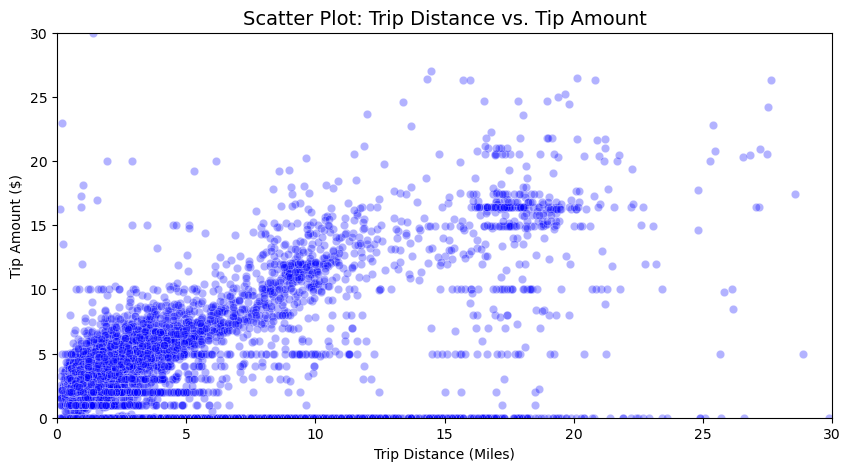

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Grab a random 10,000 trips just for fast visualization
eda_sample = df_filtered.sample(n=10000, random_state=42)

# 2. Select only the numerical columns to see how they correlate to Tip Amount
numerical_cols = ['trip_distance', 'pickup_hour', 'passenger_count', 'fare_amount', 'total_amount', 'tip_amount']
corr_matrix = eda_sample[numerical_cols].corr()

# 3. Plot the Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Heatmap: What drives the Tip Amount?", fontsize=14)
plt.show()

# 4. Scatter Plot: Trip Distance vs. Tip Amount
plt.figure(figsize=(10, 5))
sns.scatterplot(x='trip_distance', y='tip_amount', data=eda_sample, alpha=0.3, color='blue')
plt.title("Scatter Plot: Trip Distance vs. Tip Amount", fontsize=14)
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Tip Amount ($)")
plt.xlim(0, 30) # Cap at 30 miles to zoom in on the majority of trips
plt.ylim(0, 30) # Cap at $30 tips to ignore massive outliers
plt.show()

# 📝 Interpretation 1: The Correlation Heatmap
## Identifying Drivers of Tip Amount & Avoiding Data Leakage

- The Obvious Math: The heatmap shows that total_amount (0.80) and fare_amount (0.68) have the strongest mathematical correlation with tip_amount. This aligns with real-world logic, as passengers typically tip a percentage of their final bill.

- The "Data Leakage" Trap: Although highly correlated, we cannot use fare_amount or total_amount as features in our predictive model. Since our business goal is to predict tips before a trip is dispatched, the algorithm cannot "know" the final bill. Including them would result in data leakage and an artificially inflated model score.

- The Winning Feature: Excluding final financial metrics, trip_distance (0.61) emerges as the strongest predictive variable available to the driver at the start of the trip.

# 📝 Interpretation 2: The Scatter Plot (Distance vs. Tip)
## The "Fan Effect" and the Case for Tree-Based Models

- Tight Clustering at Short Distances: For trips under 5 miles, the tip amounts are highly concentrated and predictable, generally staying under $5.00.

- The "Fan Effect" (Heteroskedasticity): As trip distance increases past 10 miles, the data spreads out into a massive cloud. For a 20-mile trip, some passengers tip $5, while others tip $25. The variance in human behavior increases with distance.

- Algorithm Selection: Because the relationship between Distance and Tip is not a tight, straight line, the data violates the assumption of homoskedasticity required for Linear Regression. Therefore, we must use advanced non-linear, tree-based models (like Random Forest and XGBoost) capable of handling messy, high-variance behavioral data.

In [16]:
# 3. Feature Selection: What does the driver know BEFORE the trip starts?
features = ['pickup_hour', 'day_of_week', 'passenger_count', 'trip_distance', 'pickup_borough', 'dropoff_borough']
X_raw = df_filtered[features]
y = df_filtered['tip_amount'] 

# 4. One-Hot Encoding: Translating text into math
print("🧮 Translating neighborhoods into machine learning features...")
X = pd.get_dummies(X_raw, columns=['pickup_borough', 'dropoff_borough'], drop_first=True)

🧮 Translating neighborhoods into machine learning features...


In [18]:
X_sample = X.sample(n=150000, random_state=42)
y_sample = y.loc[X_sample.index]

X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

print("\n✅ Data is prepped, encoded, and split! Ready to train.")
print(f"Training on {len(X_train):,} trips. Testing on {len(X_test):,} trips.")


✅ Data is prepped, encoded, and split! Ready to train.
Training on 120,000 trips. Testing on 30,000 trips.


In [22]:
# ---------------------------------------------------------
# 1. Random Forest Regressor
# ---------------------------------------------------------
model_results = []
print("🌲 Training Random Forest... (This might take a moment)")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
model_results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, rf_preds),
    'R-Squared': r2_score(y_test, rf_preds)
})

🌲 Training Random Forest... (This might take a moment)


In [30]:
# ---------------------------------------------------------
# 3. XGBoost Regressor
# ---------------------------------------------------------
print("🚀 Training XGBoost...")
xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
model_results.append({
    'Model': 'XGBoost',
    'MAE': mean_absolute_error(y_test, xgb_preds),
    'R-Squared': r2_score(y_test, xgb_preds)
})

# ---------------------------------------------------------
# 🏆 Final Leaderboard
# ---------------------------------------------------------
results_df = pd.DataFrame(model_results).sort_values(by='MAE', ascending=True)
print("\n🏆 FINAL LEADERBOARD (Ranked by Lowest Error) 🏆")
display(results_df.round(4))

🚀 Training XGBoost...

🏆 FINAL LEADERBOARD (Ranked by Lowest Error) 🏆


,Model,MAE,R-Squared
1,XGBoost,1.5132,0.5316
0,Random Forest,1.5194,0.5330


🔍 Extracting Model 'Coefficients' (Feature Importances)...

🌲 Random Forest Feature Weights:


,Feature,Importance (Weight)
3,trip_distance,0.6817
4,pickup_borough_Brooklyn,0.0871
0,pickup_hour,0.0472
8,pickup_borough_Queens,0.0463
6,pickup_borough_Manhattan,0.0276
13,dropoff_borough_N/A,0.0242
14,dropoff_borough_Queens,0.0166
1,day_of_week,0.0156
11,dropoff_borough_EWR,0.0134
10,dropoff_borough_Brooklyn,0.0117


C:\Users\Ahmad Reza\AppData\Local\Temp\ipykernel_10080\445343450.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (Weight)', y='Feature', data=importance_df.head(10), palette='mako')


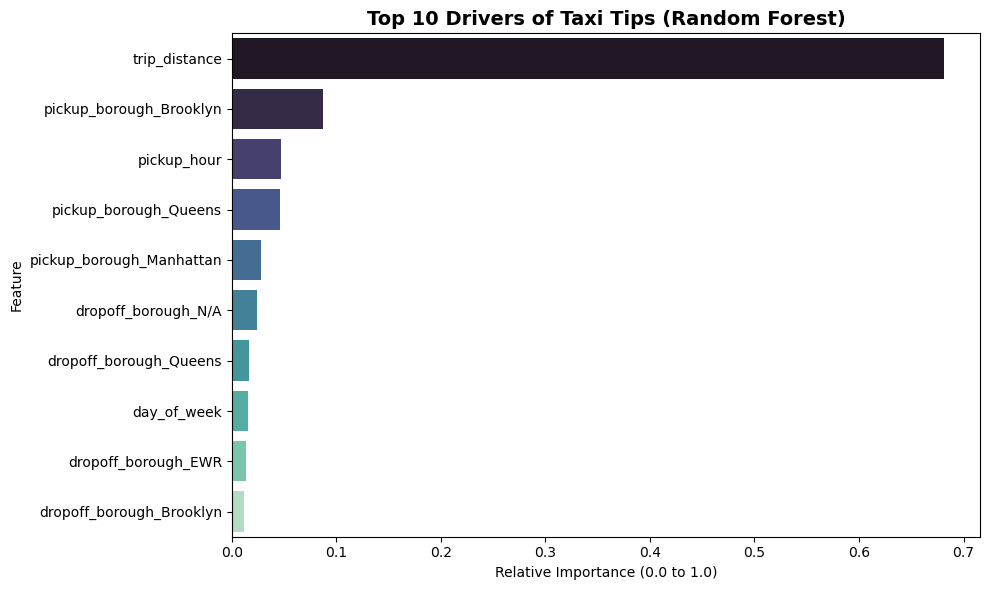

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Extracting Model 'Coefficients' (Feature Importances)...\n")

# Extract the importance scores and the feature names
importances = rf_model.feature_importances_
features = X_train.columns

# Create a clean DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance (Weight)': importances
}).sort_values(by='Importance (Weight)', ascending=False)

# Display the raw numbers
print("🌲 Random Forest Feature Weights:")
display(importance_df.head(10).round(4)) # Showing top 10 for readability

# Create a professional bar chart for your portfolio
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance (Weight)', y='Feature', data=importance_df.head(10), palette='mako')
plt.title('Top 10 Drivers of Taxi Tips (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (0.0 to 1.0)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [35]:
import joblib

print("💾 Saving the model and features for the Streamlit App...")

# 1. Save the actual Random Forest model
joblib.dump(rf_model, 'taxi_tip_model.pkl')

# 2. Save the exact column names (Crucial because of One-Hot Encoding!)
joblib.dump(list(X_train.columns), 'model_columns.pkl')

print("✅ Model successfully saved! You are ready to build the app.")

💾 Saving the model and features for the Streamlit App...
✅ Model successfully saved! You are ready to build the app.
